Max tid: 9.12 min
Max Rb: 40.0 dBHz / 10.0 kHz


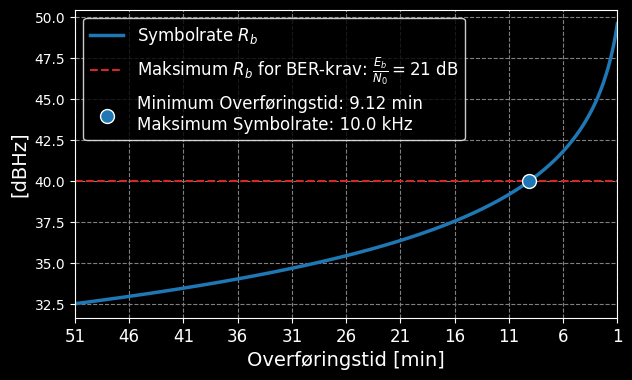

In [98]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

EIRP = 39.3 # dBW
Ls = 212.0 # dB
L0 = 5.0 # dB
G_r = 46.3 # dBi
N0 = -202.4 # dBW/Hz
Eb_N0_krav = 21.0 # dB
Margin = 10 # dB
Rb_max = EIRP - Ls - L0 + G_r - N0 - Eb_N0_krav - Margin # dBHz

tid= np.linspace(1, 51, 10000) # min
data_mengde = 5.47e6 # Symboler

data_Rb = data_mengde / (tid * 60) # Baud
data_Rb = 10 * np.log10(data_Rb) # dBHz

# find the index of the first value in data_Rb that is less than Rb_max
index = np.where(data_Rb < Rb_max)[0][0]

# find the corresponding value in tid
tid_min = tid[index] # min
print(f"Max tid: {tid_min:.2f} min")
print(f"Max Rb: {Rb_max:.1f} dBHz / {10**(Rb_max/10)*1e-3:.1f} kHz")


# --- PLOT ---
plt.figure(figsize=(7, 4))
plt.grid(True)

# Plot middelverdiene etter small-scale fading
plt.plot(tid, data_Rb, label=r'Symbolrate $R_b$', color='tab:blue', linewidth=2.5)
plt.axhline(y=Rb_max, color='tab:red', linestyle='--', label=r'Maksimum $R_b$ for BER-krav: $\frac{E_b}{N_0} = 21$ dB',linewidth=1.5)
# plot krysningspunkt
plt.plot(tid[index], data_Rb[index], 'o', markersize=10, markeredgecolor='white', markerfacecolor='tab:blue', label=f"Minimum Overføringstid: {tid[index]:.2f} min \nMaksimum Symbolrate: {10**(data_Rb[index]/10)*1e-3:.1f} kHz")
plt.grid(which='both', linestyle='--',  color='gray')
plt.xlabel('Overføringstid [min]', fontsize=14)
plt.ylabel('[dBHz]', fontsize=14)
plt.xticks(np.arange(min(tid), max(tid)+1, 5), fontsize=12)
plt.xlim([min(tid), max(tid)])
# invert x axis
plt.gca().invert_xaxis()
plt.legend(loc='upper left', fontsize=12, edgecolor='white')
plt.savefig("Figurer/Link_symbolrate.pdf", bbox_inches="tight")
plt.show()


Minimum Aperturdiameter: 0.53 m


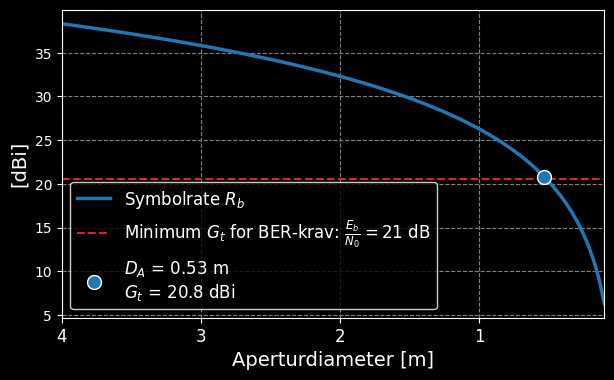

In [101]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

P_t =11.4 # dBW
Ls = 212.0 # dB
L0 = 5.0 # dB
G_r = 46.3 # dBi
N0 = -202.4 # dBW/Hz
Eb_N0_krav = 21.0 # dB
Margin = 10 # dB
Rb = 32.6 # dBHz

G_t_min = -P_t + Eb_N0_krav + N0 + Ls + L0 - G_r + Rb + Margin # dBi

eta = 0.8 # Antenneeffektivitet
f= 2.2e9 # Hz
c= 3e8 # m/s

D_a = np.linspace(0.1, 4, 100) # m
G_t = 10*np.log10(eta * (np.pi * D_a * f / c)**2) # dBi

# finn D_a der G_t er lik G_t_min
index = np.where(G_t > G_t_min)[0][0]
D_a_min = D_a[index] # m

print(f"Minimum Aperturdiameter: {D_a_min:.2f} m")
# --- PLOT ---
plt.figure(figsize=(7, 4))
plt.grid(True)

# Plot middelverdiene etter small-scale fading
plt.plot(D_a, G_t, label=r'Symbolrate $R_b$', color='tab:blue', linewidth=2.5)
plt.axhline(y=G_t_min, color='tab:red', linestyle='--', label=r'Minimum $G_t$ for BER-krav: $\frac{E_b}{N_0} = 21$ dB',linewidth=1.5)
# plot krysningspunkt
plt.plot(D_a[index], G_t[index], 'o', markersize=10, markeredgecolor='white', markerfacecolor='tab:blue', label=r"$D_A$ = "+f"{D_a[index]:.2f} m \n"+r"$G_t$ = "+f"{G_t[index]:.1f} dBi")
plt.grid(which='both', linestyle='--',  color='gray')
plt.xlabel('Aperturdiameter [m]', fontsize=14)
plt.ylabel('[dBi]', fontsize=14)
plt.xticks(np.arange(0, 10+0.1, 1), fontsize=12)
plt.xlim([min(D_a), max(D_a)])
# invert x axis
plt.gca().invert_xaxis()
plt.legend(loc='lower left', fontsize=12, edgecolor='white')
plt.savefig("Figurer/Link_antenne.pdf", bbox_inches="tight")
plt.show()